# 07.07 - Custom Dataset and DataLoader

**Daily output:** `ImageDataset` from a CSV with `image_path,label`, plus printed batch shapes and labels.

Today turns image files into model-ready batches: CSV metadata, label mapping, custom `Dataset`, transforms, `DataLoader`, train/validation behavior, imbalance checks, and visual sanity checks.

**Notebook type:** Practice notebook with theory, exercises, and TODO cells.


## Dataset/DataLoader Mental Model

A `Dataset` answers two questions: how many examples exist, and how do I load one example? A `DataLoader` handles batching, shuffling, workers, and stacking examples into tensors.

For image classification, a CSV usually has `image_path` and `label`. The model needs integer class IDs, so create a stable mapping like `{'cat': 0, 'dog': 1}`.


In [1]:
from pathlib import Path
import csv
import random
import pandas as pd

import numpy as np
from PIL import Image, ImageDraw
import torch
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed. Visualization examples will be skipped.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path("_day07_image_data")
IMG_DIR = ROOT / "images"
CSV_PATH = ROOT / "labels.csv"
IMG_DIR.mkdir(parents=True, exist_ok=True)


## Create a Tiny Image Dataset

This notebook generates a synthetic image dataset so it runs without downloads. In a contest, replace this with the provided CSV and image folder.


In [2]:
def make_colored_image(label, size=(80, 80), seed=0):
    rng = np.random.default_rng(seed)
    base = {
        "red": np.array([220, 40, 40], dtype=np.uint8),
        "green": np.array([40, 180, 80], dtype=np.uint8),
        "blue": np.array([50, 90, 220], dtype=np.uint8),
    }
    arr = np.zeros((size[1], size[0], 3), dtype=np.uint8)
    arr[...] = base[label]
    noise = rng.normal(0, 18, size=arr.shape).astype(np.int16)
    arr = np.clip(arr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, mode="RGB")
    ImageDraw.Draw(img).rectangle([10, 10, 30, 30], outline=(255, 255, 255), width=2)
    return img

counts = {"red": 16, "green": 10, "blue": 6}
rows = []
for label, count in counts.items():
    for i in range(count):
        path = IMG_DIR / f"{label}_{i:02d}.png"
        make_colored_image(label, seed=1000 + i).save(path)
        rows.append({"image_path": str(path), "label": label})
random.shuffle(rows)

with CSV_PATH.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["image_path", "label"])
    writer.writeheader()
    writer.writerows(rows)

print("wrote", CSV_PATH)
print("rows:", len(rows))
print(rows[:3])


wrote _day07_image_data\labels.csv
rows: 32
[{'image_path': '_day07_image_data\\images\\blue_00.png', 'label': 'blue'}, {'image_path': '_day07_image_data\\images\\red_05.png', 'label': 'red'}, {'image_path': '_day07_image_data\\images\\red_10.png', 'label': 'red'}]


C:\Users\Dell\AppData\Local\Temp\ipykernel_12816\4125518891.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode="RGB")


## Read CSV and Build Label Mapping

The exact integer IDs do not matter as much as consistency. Save `label_to_id` and `id_to_label` with your experiment notes or checkpoint.


In [3]:
# TODO 07-A: Read CSV and build label mapping.
# Implement read_label_csv(csv_path).
# Build:
# - samples
# - unique_labels
# - label_to_id
# - id_to_label

def read_label_csv(csv_path):
    df = pd.read_csv(csv_path)
    samples = []
    unique_labels = set()
    label_to_id = {}
    id_to_label = {}
    curidx = 0
    for idx, row in df.iterrows() : 
        label = row["label"]
        path = row["image_path"]
        if label not in unique_labels : 
            label_to_id[label] = curidx
            id_to_label[curidx] = label
            unique_labels.add(label)
            curidx += 1
        samples.append({"image_path" : path, "label" : label})

    return samples, unique_labels, label_to_id, id_to_label

samples, unique_labels, label_to_id, id_to_label = read_label_csv(CSV_PATH)
print(samples[0])
print(label_to_id)
print(id_to_label)

# TODO: read CSV_PATH and print first row plus mappings.


{'image_path': '_day07_image_data\\images\\blue_00.png', 'label': 'blue'}
{'blue': 0, 'red': 1, 'green': 2}
{0: 'blue', 1: 'red', 2: 'green'}


## Minimal Transforms

Writing these once makes the image contract memorable: PIL RGB image in, `[C, H, W]` float tensor out.


In [17]:
# TODO 07-B: Minimal transforms.
# Implement Resize, ToTensor, Normalize, Compose.
# Contract: PIL RGB image -> CHW float tensor.

class Resize:
    def __init__(self, size) : 
        self.size = size
    def __call__(self,image) :
        return image.resize(self.size)

class ToTensor:
    def __call__(self,image) : 
        arr = np.array(image)
        tensor = torch.tensor(arr, dtype = torch.float32)
        tensor = tensor/255.0
        tensor = tensor.permute(2,0,1)
        return tensor

class Normalize:
    def __init__(self,mean,std) :
        self.mean = torch.tensor(mean,dtype = torch.float32).view(3,1,1)
        self.std = torch.tensor(std, dtype = torch.float32).view(3,1,1)
    def __call__(self,tensor) :
        return (tensor-self.mean)/self.std

class Compose:
    def __init__(self, transforms) :
        self.transforms = transforms
    def __call__(self,image) :
        if self.transforms == None : return np.array(image)
        for transform in self.transforms : 
            image = transform(image)
        return image

IMAGE_SIZE = (64,64)
mean = [0.485,0.456,0.406]
std = [0.229,0.224,0.225]

train_transform = [
    Resize(IMAGE_SIZE),
    ToTensor(),
    Normalize(mean,std)
]
val_transform = [
    Resize(IMAGE_SIZE),
    ToTensor(),
    Normalize(mean,std)
]
# TODO: create train_transform and val_transform.


## Build `ImageDataset`

Keep the Dataset focused: load one row, open image, transform it, map the label, and return useful metadata for debugging.


In [5]:
# TODO 07-C: Build ImageDataset.
# Implement __len__ and __getitem__.
# Return a dict with image, label, label_name, path.

class ImageDataset(Dataset):
    def __init__(self, rows, label_to_id, transform=None, path_col="image_path", label_col="label"):
        self.rows = rows
        self.label_to_id = label_to_id
        self.transform = transform
        self.path_col = path_col
        self.label_col = label_col


    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        item = self.rows[idx]
        path = item[self.path_col]
        label_name = item[self.label_col]
        image = Image.open(path)
        compose = Compose(self.transform)
        image = compose(image)
        label = self.label_to_id[label_name]
        return {
            "image" : image,
            "label" : torch.tensor(label,dtype = torch.long),
            "label_name" : label_name,
            "path" : path
        }

full_ds = ImageDataset(samples,label_to_id,transform = train_transform)
print(full_ds[0])
# TODO: instantiate full_ds and inspect one item.


{'image': tensor([[[-1.4500, -1.3473, -1.0733,  ..., -0.8678, -0.8678, -0.8678],
         [-1.4158, -1.3302, -1.0904,  ..., -0.9363, -0.9363, -0.9363],
         [-1.2959, -1.2617, -1.1589,  ..., -1.0904, -1.0904, -1.0904],
         ...,
         [-1.6213, -1.5528, -1.3815,  ..., -1.3473, -1.2445, -1.2103],
         [-1.5870, -1.5014, -1.2788,  ..., -1.5014, -1.4158, -1.3987],
         [-1.5699, -1.4843, -1.2445,  ..., -1.5699, -1.4843, -1.4672]],

        [[-0.6176, -0.6001, -0.5126,  ..., -0.7052, -0.9503, -1.0553],
         [-0.6176, -0.6001, -0.5301,  ..., -0.6877, -0.8803, -0.9678],
         [-0.6352, -0.6176, -0.5651,  ..., -0.6352, -0.7402, -0.7752],
         ...,
         [-0.7577, -0.6877, -0.4951,  ..., -0.6001, -0.4251, -0.3550],
         [-0.8627, -0.7577, -0.4776,  ..., -0.7227, -0.6352, -0.6176],
         [-0.8978, -0.7752, -0.4776,  ..., -0.7577, -0.7227, -0.7052]],

        [[ 2.6400,  2.5877,  2.2740,  ...,  2.2566,  2.1868,  2.1520],
         [ 2.6226,  2.5180,  2.2391

## DataLoader Batches

The default collate function stacks tensors and keeps strings as lists/tuples. For images, your expected batch shape is `[B, C, H, W]`.


In [6]:
# TODO 07-D: DataLoader batches.
# Create DataLoader(full_ds, batch_size=8, shuffle=True, num_workers=0).
# Print batch keys, image shape, label shape/dtype, label names, and paths.

batch_size = 8
data_loader = DataLoader(full_ds, batch_size = batch_size, shuffle = True, num_workers = 0)
batch = next(iter(data_loader))
print(batch.keys())
print(batch["image"].shape)
print(batch["label"].shape, batch["label"].dtype)
print(batch["label_name"])
print(batch["path"])


dict_keys(['image', 'label', 'label_name', 'path'])
torch.Size([8, 3, 224, 224])
torch.Size([8]) torch.int64
['blue', 'green', 'red', 'blue', 'blue', 'green', 'red', 'red']
['_day07_image_data\\images\\blue_00.png', '_day07_image_data\\images\\green_03.png', '_day07_image_data\\images\\red_03.png', '_day07_image_data\\images\\blue_04.png', '_day07_image_data\\images\\blue_01.png', '_day07_image_data\\images\\green_01.png', '_day07_image_data\\images\\red_13.png', '_day07_image_data\\images\\red_02.png']


## Visual Batch Sanity Check

Always visualize a batch before training. It catches wrong labels, wrong colors, broken normalization, and accidental path mistakes.


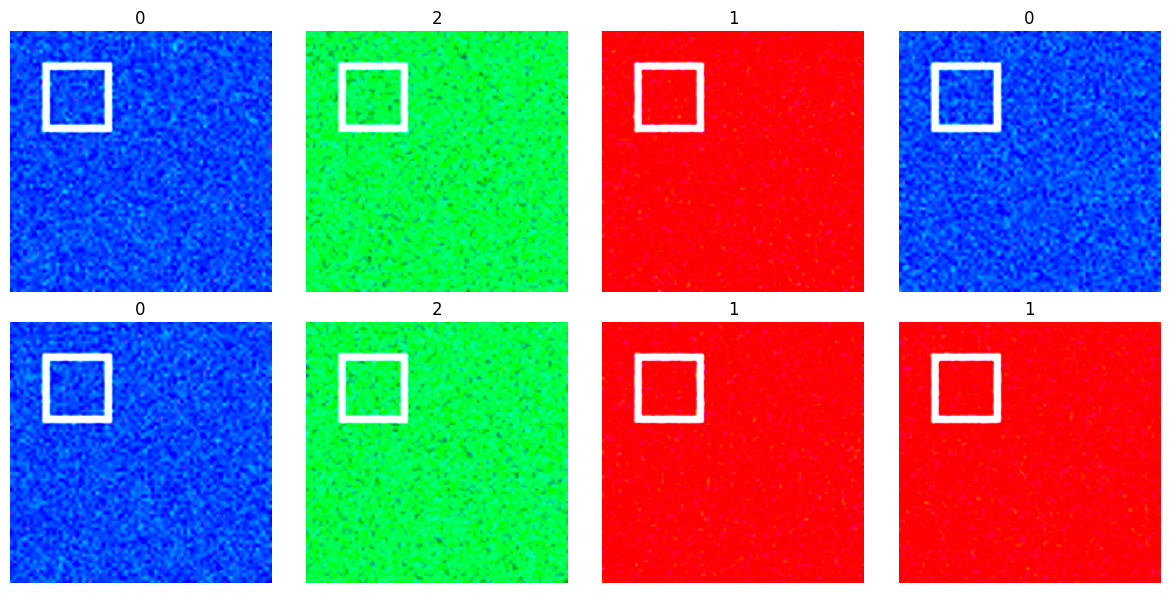

In [7]:
import math
import matplotlib.pyplot as plt
# TODO 07-E: Visual batch sanity check.
# Implement unnormalize_for_display(tensor).
# If matplotlib is available, plot up to 8 images with labels.

def unnormalize_for_display(tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)

    unnormalized_tensor = tensor * std + mean
    unnormalized_tensor = torch.clamp(unnormalized_tensor,0,1)
    
    return unnormalized_tensor

cols = 4
rows = math.ceil(batch_size/4)

fig,axes = plt.subplots(rows, cols, figsize = (12, rows*3))
axes = axes.flatten()

for i in range(len(axes)) : 
    ax = axes[i]

    if i < batch_size :
        img = unnormalize_for_display(batch["image"][i])
        label = batch["label"][i]
        img = img.permute(1,2,0)
        ax.imshow(img)
        ax.set_title(label.item())
        ax.axis("off")
    else : ax.axis("off")

plt.tight_layout()
plt.show()


# TODO: visualize one batch.


## Train/Validation Split

For a tiny demo, `random_split` is fine. For real competitions, use a stratified split so every class appears in both train and validation.


In [8]:
# TODO 07-F: Train/validation split.
# Use random_split with a fixed generator.
# Create train_loader with shuffle=True and val_loader with shuffle=False.
# Print sizes and one batch shape from each.

train_size = int(0.8 * len(full_ds))
test_size = len(full_ds) - train_size

train_ds, test_ds = random_split(full_ds,(train_size,test_size))

train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)

print(len(train_loader.dataset))
print(len(test_loader.dataset))

train_batch = next(iter(train_loader))
test_batch = next(iter(test_loader))

print(len(train_batch))
print(len(test_batch))

25
7
4
4


## Imbalance Check

Count classes before training. If classes are imbalanced, consider class-weighted loss, a sampler, more data, or metric-aware thresholding.


In [9]:
# TODO 07-G: Imbalance check.
# Count labels.
# Build optional WeightedRandomSampler.
# Print one sampled batch of label names.

def count_labels(rows):
    count = {}
    unique_labels = set()
    for i in rows : 
        if i["label"] not in unique_labels : 
            unique_labels.add(i["label"])
            count[i["label"]] = 0
        count[i["label"]] += 1
    return count

count = count_labels(samples)

class_weights = {}
for i in count.keys() : 
    class_weights[i] = 1/count[i]

sample_weights = [
    class_weights[row["label"]]
    for row in samples
]

sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(samples),
    replacement = True
)

balanced_loader = DataLoader(full_ds,batch_size = batch_size,sampler = sampler, num_workers= 0)
# TODO: create sampler and balanced_loader.


## Robust Dataset Variant

During development, failing fast is best. For long training runs, you may choose a placeholder image and keep an error flag.


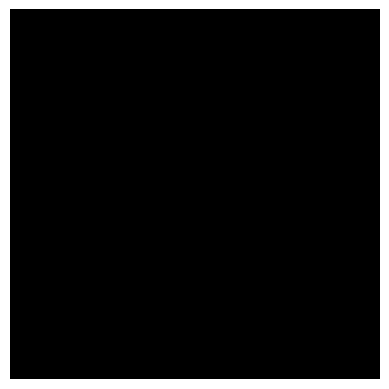

In [19]:
# TODO 07-H: Robust Dataset variant.
# Extend ImageDataset.
# If strict=True, raise image loading errors.
# If strict=False, return a black placeholder image and include load_error.

class RobustImageDataset(ImageDataset):
    def __init__(self, rows, label_to_id, transform=None, path_col="image_path", label_col="label", strict = False):
        super().__init__(rows,label_to_id,transform,path_col,label_col)
        self.strict = strict
    def __getitem__(self,idx) : 
        item = self.rows[idx]
        path = item[self.path_col]
        label_name = item[self.label_col]
        label = self.label_to_id[label_name]
        try : 
            image = Image.open(path)
            compose = Compose(self.transform)
            image = compose(image)
        except Exception as e : 
            if self.strict : 
                raise e
            image = Image.new("RGB",(224,224),color = (0,0,0))
            compose = Compose(self.transform)
            image = compose(image)
            return {
            "image" : image,
            "label" : torch.tensor(label,dtype = torch.long),
            "label_name" : label_name,
            "path" : path,
            "load_error" : True
            }   
        return {
            "image" : image,
            "label" : torch.tensor(label,dtype = torch.long),
            "label_name" : label_name,
            "path" : path
        }

bad_samples = samples.copy()

bad_samples[0] = bad_samples[0].copy()
bad_samples[0]["image_path"] = "missing_file.jpg"

robust_ds = RobustImageDataset(bad_samples,label_to_id,transform = train_transform)

item = robust_ds[0]
img = unnormalize_for_display(item["image"])
img = img.permute(1,2,0)
plt.imshow(img)
plt.axis("off")
plt.show()
        

# TODO: test with a missing image path.


## Test Cases

Run this cell after completing the TODO cells above. A correct implementation should print `Day 07 tests passed`.


In [20]:
def run_day07_tests():
    required_names = [
        "read_label_csv",
        "Resize",
        "ToTensor",
        "Normalize",
        "Compose",
        "ImageDataset",
        "count_labels",
        "RobustImageDataset",
    ]
    for name in required_names:
        assert name in globals(), f"Missing function or class: {name}"
        assert callable(globals()[name]), f"{name} must be callable"

    test_samples, x, y, z = read_label_csv(CSV_PATH)
    assert len(test_samples) == len(samples)
    assert {"image_path", "label"}.issubset(test_samples[0].keys())
    assert set(label_to_id.keys()) == {"blue", "green", "red"}

    test_ds = ImageDataset(test_samples, label_to_id, transform=val_transform)
    item = test_ds[0]
    assert set(["image", "label", "label_name", "path"]).issubset(item.keys())
    assert item["image"].shape == (3, 64, 64), f"Expected CHW image, got {item['image'].shape}"
    assert item["image"].dtype == torch.float32
    assert item["label"].dtype == torch.long
    assert item["label_name"] in label_to_id
    assert Path(item["path"]).exists()

    test_loader = DataLoader(test_ds, batch_size=5, shuffle=False, num_workers=0)
    batch = next(iter(test_loader))
    assert batch["image"].shape == (5, 3, 64, 64)
    assert batch["label"].shape == (5,)
    assert batch["label"].dtype == torch.long

    counts = count_labels(test_samples)
    assert counts == {"red": 16, "green": 10, "blue": 6}, counts
    assert sum(counts.values()) == len(test_samples)

    broken_rows = test_samples[:2] + [{"image_path": str(ROOT / "missing.png"), "label": "red"}]
    robust_ds = RobustImageDataset(broken_rows, label_to_id, transform=val_transform, strict=False)
    bad_item = robust_ds[2]
    assert "load_error" in bad_item
    assert bad_item["image"].shape == (3, 64, 64)
    assert bad_item["label"].dtype == torch.long

    print("Day 07 tests passed")

run_day07_tests()


Day 07 tests passed


## Day 07 Checklist

Check CSV columns, image paths, label mapping, one dataset item, one DataLoader batch, train loader shuffle, validation loader no shuffle, transform differences, class counts, and a visual batch.
